# 확률적 경사 하강법

매주 7개 종류의 생선 중 일부를 무작위로 골라 모델을 학습할 수 있게 영업팀에서 훈련 데이터를 제공하고 있다.

하지만 수산물을 공급하겠다는 곳이 너무 많아 샘플을 골라내는 일이 너무 힘들다. 게다가 추가되는 수산물은 아직 샘플을 가지고 있지도 않다. 영업 팀은 새로운 생선이 도착하는 대로 가능한 즉시 훈련 데이터를 제공하겠다고 했으나, 어느 생선이 먼저 올지도, 모든 생선이 도착할 때까지 기다릴 수도 없다. 

==> 즉 문제는 학습할 훈련 데이터가 한번에 준비되는 것이 아니라, 조금씩 전달된다는 것이다. 도착하는대로 생선을 판매해야 하므로, 데이터가 쌓일 때 까지 무작정 기다릴 수 없다.

==> Bad 방법 1. 기존의 훈련 데이터에 새로운 데이터를 추가하여 모델을 매일매일 다시 훈련하는 것은 어떨까?  하지만 시간이 지날 수록 모델을 훈련하기 위해 서버를 증설해야 하고 몇 년이 지나면 감당할 수 없다. 즉 지속가능한 방법이 아니다.

==> Bad방법 2. 새로운 데이터가 추가될 때, 기존의 데이터를 버림으로써 훈련 데이터를 일정한 크기로 유지하는 것은 어떨까? 하지만 다른 데이터에 없는 중요한 생선데이터가 포함되어있다면 큰일이다.

**Great 방법: 앞서 훈련한 모델을 버리지 않고, 새로운 데이터에 대해서만 조금씩 더 훈련**을 하도록 하자. 이런식의 훈련 방식을 **'점진적 학습'** 또는 **'온라인 학습'**이라고 한다. **대표적인 점진적 학습 알고리즘은 '확률적 경사 하강법'**이다.

# 어떤 알고리즘인지, 왜 중요한지?

확률적 경사 하강법에서 '확률적'이라는 말은 '무작위하게' 혹은 '랜덤하게'의 기술적인 표현이다.

확률적 경사 하강법은 가장 가파른 경사를 따라 원하는 지점에 도달하는 것이 목표이다. 만약 한번에 걸음이 너무 크면 경사를 따라 내려가지 못하고 오히려 올라갈 수도 있다.

천천히 조금씩 내려오는 것이 중요하다. 이렇게 내려오는 과정이 경사 하강법 모델을 훈련하는 것이다.

그럼이제 **'확률적'이라는 말을 이해해보자. 경사 하강법으로 내려올 때 가장 가파른 길을 찾는 방법은 무엇일까? 훈련 세트를 사용해 모델을 훈련할 때 전체 샘플을 사용하지 않고, 딱 하나의 샘플을 훈련세트에서 랜덤하게 골라 가장 가파른 길을 찾는다. 이처럼 훈련 세트에서 랜덤하게 하나의 샘플을 고르는 것이 바로 '확률적' 경사 하강법 이다.**

조금 더 자세히 설명하면 '확률적' 경사 하강법은 훈련 세트에서 랜덤하게 하나의 샘플을 선택하여 가파른 경사를 조금 내려간다. 그 다음 훈련세트에서 랜덤하게 또 다른 샘플을 하나 선택하여 경사를 조금 내려간다. 이런식으로 전체 샘플을 모두 사용할 때 까지 계속한다.

만약 모든 훈련 샘플을 사용했는데도 산을 못내려오면 어떻게 할까? 답은 다시 처음부터 시작하는 것이다.

**훈련 세트에 모든 샘플을 다시 채워 넣고, 다시 랜덤하게 하나의 샘플을 선택해 이어서 경사를 내려간다.** 이렇게 만족할만한 위치에 도달할 때 까지 계속 내려가면 된다. **확률적 경사 하강법에서 훈련 세트를 한 번 모두 사용하는 과정을 '에포크(epoch)'**라고 부르고, 일반적으로 수십, 수백번 이상 epoch를 수행한다.

무작위로 샘플을 선택해 내려가는게 무책임한 것처럼 보이지만, 그렇기 때문에 아주 조금씩 내려가야 한다. **실제로는 1개의 훈련 샘플을 고르지 않고, 무작위로 몇 개의 샘플을 선택해서 경사를 따라 내려가는데, 이렇게 여러 개의 샘플을 무작위로 선택해 경사 하강법을 수행하는 방식을 '미니배치 경사 하강법'**이라고 한다. 실전에서 많이 사용한다.

극단적으로 한 번 경사로를 따라 이동하기 위해 전체 샘플을 사용할 수도 있는데, 이는 배치 경사 하강법이라고 부른다. 전체 데이터를 사용하면 그만큼 컴퓨터 자원을 많이 사용(램에 데이터 적재 등)한다. 어떤 경우는 데이터가 너무 많아 한 번에 전체 데이터를 모두 읽을 수도 없을지 모른다.

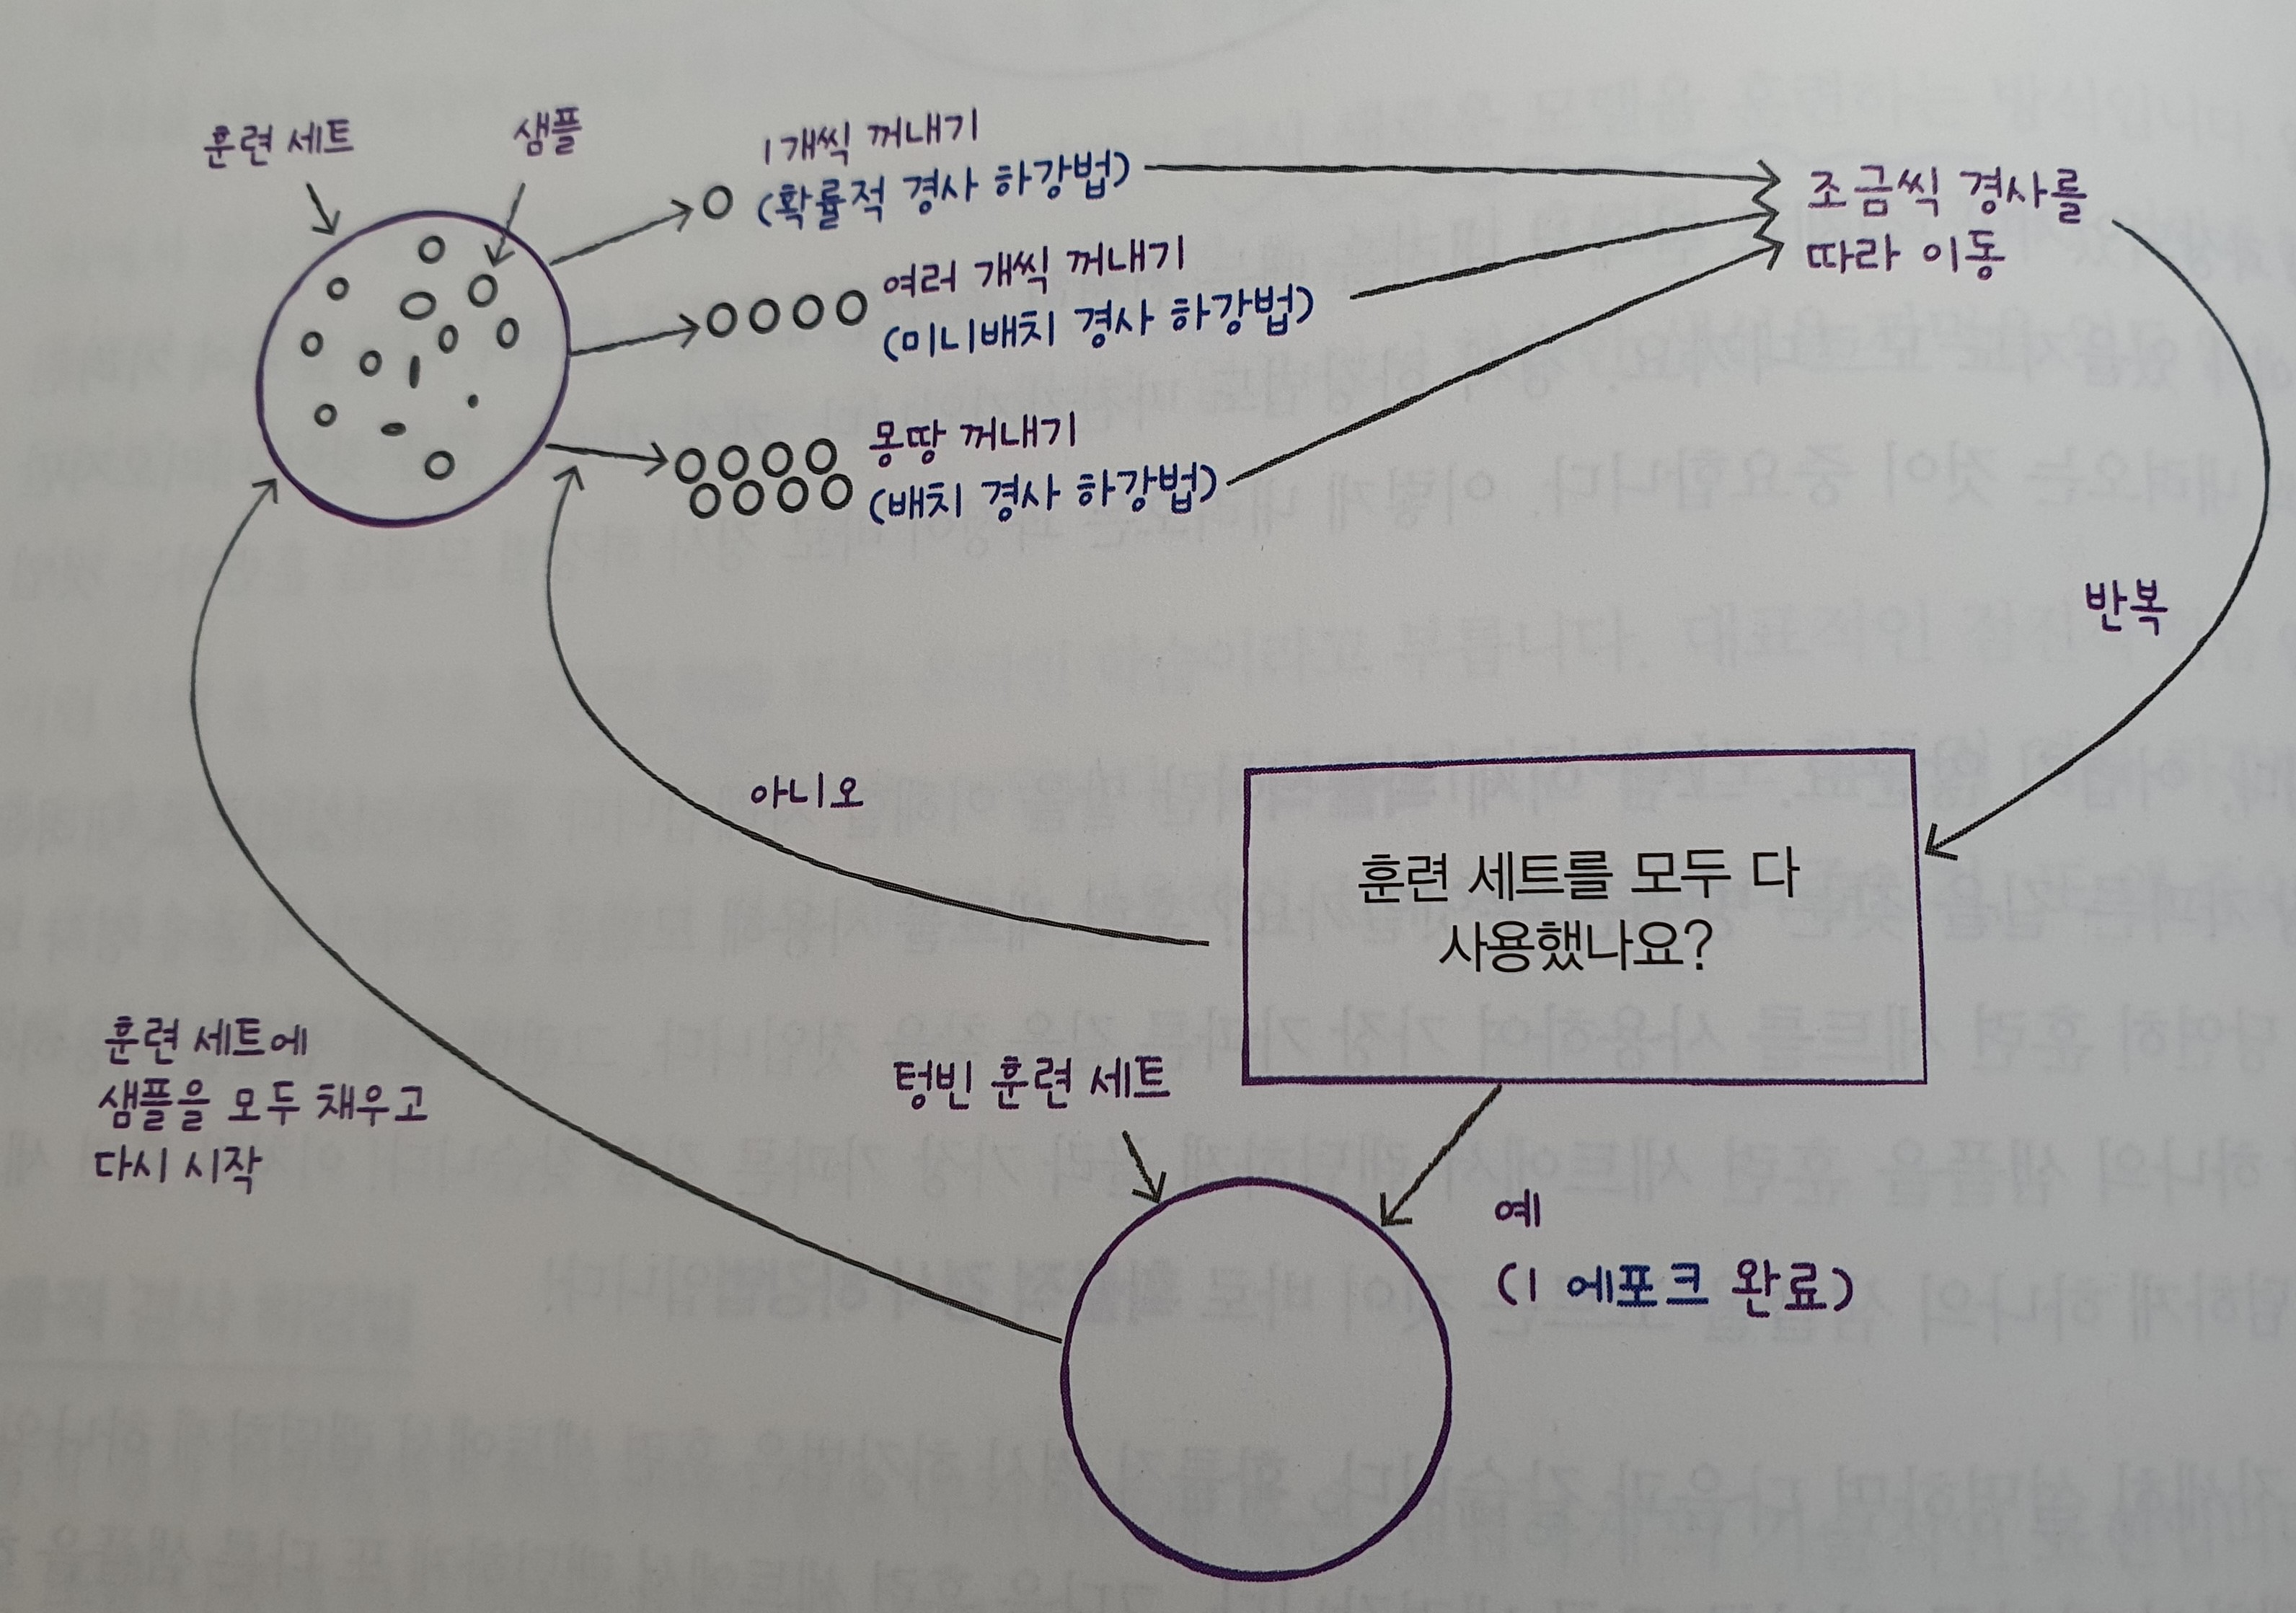

## '산'은 무엇을 의미하나?

확률적 경사 하강법으로 훈련을 하여 조금씩 산을 내려온다고 하였는데, 이 산은 어떤걸 의미할까?

**이 산은 '손실 함수(loss function)'이다.**

**'손실 함수'는 어떤 문제에서 머신러닝 알고리즘이 얼마나 엉터리인지 측정하는 기준이다.** 즉, 이 함수의 값이 작을 수록 좋은데, 어떤 값이 최솟값인지는 알지 못한다. 가능한 많이 찾아보고 만족할만한 수준이라면 산을 다 내려왔다고 인정해야 한다. 이 값을 찾아서 조금씩 이동하려면 확률적 경사 하강법이 잘 맞다.

(비용 함수(cost function)도 엄격히 구분하지 않고 손실 함수와 혼용을 하기도 하지만, 엄밀히 말하면 손실 함수는 '샘플 하나'에 대한 손실을 정의하고, 비용 함수는 훈련 세트에 있는 모든 샘플에 대한 손실함수의 합을 말한다. 보통 이를 엄격히 구분하지 않고 섞어서 사용한다.)

# 그럼 손실 함수는 어떤걸 사용하나?

예를 들어 '정확도'를 손실함수로 활용한다고 해보자.

분류에서 손실을 '정답을 못 맞추는' 것이라고 하고 이진분류를 생각해보면, 도미는 양성 클래스, 빙어는 음성 클래스라고 해보자.

타깃이 도미일때 예측이 맞거나/틀리거나, 타깃이 빙어일때 예측이 맞거나/틀리거나하는 총 4가지 경우가 있을 것이다. 이 때 정확도는 2/4 = 0.5이다.

하지만 정확도에는 치명적인 단점이 있다. 예를 들어 앞의 그림과 같이 4개의 샘플만 있다면 가능한 정확도는 0, 0.25, 0.5, 0.75, 1.0 다섯 가지 뿐이다. 앞에서 경사 하강법을 사용할 때 아주 조금씩 내려온다고 했는데, 정확도가 이렇게 듬성듬성 하다면 경사 하강법을 이용해 조금씩 움직일 수 없다.

**'산의 경사면은 연속적(미분가능)이어야 한다.'**

#분류에서 손실함수 정해보기

예측             정답(타깃)

1         =          1

0        !=          1

0         =          0

1        !=          0

가령 위 샘플 4개의 예측 확률을 각각 0.9, 0.3, 0.2, 0.8이라고 가정해보자. 첫 번째 샘플부터 하나씩 어떻게 손실 함수를 만들 수 있는지 살펴보자.

첫 번째 샘플의 예측은 0.9이므로, 양성 클래스의 타킷인 1과 곱한 다음, 음수로 바꿀 수 있다. 이 경우 예측이 1에 가까울 수록 좋은 모델이다. 손실을 계산해보면 예측 0.9와 타깃 1을 곱하고 음수로 바꾸면 -0.9이다. 예측이 1에 가까울 수록 손실이 작기 때문에 이 값을 손실로 사용해도 좋다.

예측  정답(타깃)
0.9 x 1 --> **-0.9**

두 번째 샘플의 예측은 0.3인데, 타깃이 양성 클래스(1)인데 거리가 멀다. 위처럼 예측 x 타깃하여 음수로 바꿔보면 **-0.3**이다. 확실히 첫 번째 샘플의 손실인 -0.9보다 높은 손실이 된다.

세 번째 샘플을 보자. 이 샘플의 타깃은 음성 클래스라 0이다. 이 값을 예측 확률인 0.2와 그대로 곱하면 무조건 0이 되므로, 타깃을 마치 양성 클래스처럼 1로 만들고, 타깃과 곱한뒤 -1을 곱해주자.

i) 양성 클래스로: 1-0.2 = 0.8 (예측 변화)

ii) 타깃(0->1)과 곱: 0.8 x 1 = 0.8

iii) 음수로 변화: **-0.8**

네 번째 샘플도 음성 클래스에 대한 타깃이므로 세 번째 클래스처럼 손실을 계산해보자.

i) 양성 클래스로: 1-0.8 = 0.2

ii) 타깃(0->1)과 곱: 0.2 x 1 = 0.2

iii) 음수로 변화: **-0.2**

네 번째 샘플의 손실이 -0.2로 가장 높다. 예측 확률을 사용해 이런 방식으로 계산하면 연속적인 손실 함수를 얻을 수 있다.

여기서 예측 확률에 로그를 적용하면 더 좋다. 예측 확률의 범위는 0~1사이인데 로그함수는 이 사이에서는 음수가 되므로, 최종 손실 값은 양수가 된다. 손실이 양수가 되면 이해하기 더 쉽다.

또 로그함수는 0에 가까울수록 아주 큰 음수가 되기 때문에 손실을 아주 크게 만들어 모델에 큰 영향을 미칠 수 있다.

* x축: 예측 확률, y축: Log

즉, 0~1사이의 예측 확률(x축)에 대해 손실함수 값 계산은 아래와 같다.
* 타깃이 양성 클래스일 때: -log(예측 확률)

* 타깃이 음성 클래스일 때: -log(1-예측 확률)

# 여기까지 길게 정의한 손실함수는

**'로지스틱 손실 함수' 또는 '이진 크로스엔트로피 손실 함수'라고 한다.**

여기서는 이진 분류를 예로 들어 설명했지만, 다중 분류도 매우 비슷한 손실 함수를 사용한다. 다중 분류에서 사용하는 손실 함수를 '크로스엔트로피 손실 함수'라고 한다.

**확률적 경사 하강법 훈련에서 이진 분류에서는 '로지스틱 손실 함수'를 사용하고, 다중 분류는 '크로스엔트로피 손실 함수'를 사용한다.**

(그럼 회귀에서는 어떤 손실 함수를 사용할까? --> 평균 제곱 오차(mean squared error)를 사용하여 타깃에서 예측을 뺀 값을 제곱한 다음 모든 샘플에 평균한 값을 사용한다.)

# SGDClassifier

확률적 경사 하강법을 사용한 분류 모델을 만들어보자.

In [1]:
import pandas as pd
fish = pd.read_csv('https://bit.ly/fish_csv_data')

In [2]:
# 그 다음 Species 열을 제외한 나머지 5개는 입력 데이터로 사용한다.
# Species열은 타깃 데이터이다.

fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()
fish_target = fish['Species'].to_numpy()

In [3]:
# train_test_split으로 데이터를 훈련/테스트 세트로 나눈다.
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(fish_input, fish_target, random_state=42)

In [4]:
# 훈련 세트와 테스트 세트의 특성간 표준화 전처리를 한다.
# 계속 강조하지만 훈련 세트에서 학습한 통계 값으로 테스트 세트도 변환해야 한다.

from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [5]:
# 사이킷런에서 확률적 경사 하강법을 제공하는 대표적인 분류용 클래스는 SGDClassifier이다.
# sklearn.linear_model 패키지 아래에 있다.

from sklearn.linear_model import SGDClassifier

sgdc = SGDClassifier(loss='log', max_iter=10, random_state=42)
# loss='log'는 로지스틱 손실 함수로 지정, max_iter=10은 epoch을 10으로 설정한 것.

sgdc.fit(train_scaled, train_target)
print(sgdc.score(train_scaled, train_target))
print(sgdc.score(test_scaled, test_target))

0.773109243697479
0.775


/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_stochastic_gradient.py:700: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning,


In [8]:
# 앞서 이야기 한 것처럼 확률적 경사 하강법은 점진적 학습이 가능하다.
# SGDClassifier 객체를 다시 만들지 않고 훈련한 모델 sgdc를 추가로 더 훈련해보자.
# 모델을 이어서 훈련할 때는 partial_fit()메서드를 사용한다.
# 이 메서드는 fit과 사용법이 같지만, 호출할 때마다 1 에포크씩 이어서 훈련할 수 있다.

sgdc.partial_fit(train_scaled, train_target)
print(sgdc.score(train_scaled, train_target))
print(sgdc.score(test_scaled, test_target))
# 이전보다 점수가 높아진걸 확인할 수 있다. 그런데 무작정 많이 반복할 수는 없고 어떤 기준이 필요하다.

0.8319327731092437
0.8


# 에포크와 과대/과소 적합

확률적 경사 하강법을 사용한 모델은 에포크 횟수에 따라 과소적합이나 과대적합이 될 수 있다.

에포크 횟수가 적으면 모델이 훈련 세트를 덜 학습한다. 마치 산을 다 내려오지 못하고 훈련을 마치는 셈이다. 에포크 횟수가 충분히 많으면 훈련 세트를 완전히 학습할 것이다.

바꿔 말하면 적은 에포크 횟수 동안에 훈련한 모델은 훈련 세트와 테스트 세트에 잘 맞지 않는 과소적합된 모델일 가능성이 높다. 반대로 많은 에포크 횟수 동안에 훈련한 모델은 훈련 세트에 너무 잘 맞아서 테스트 세트에는 오히려 점수가 나쁜 과대적합된 모델일 가능성이 높다.

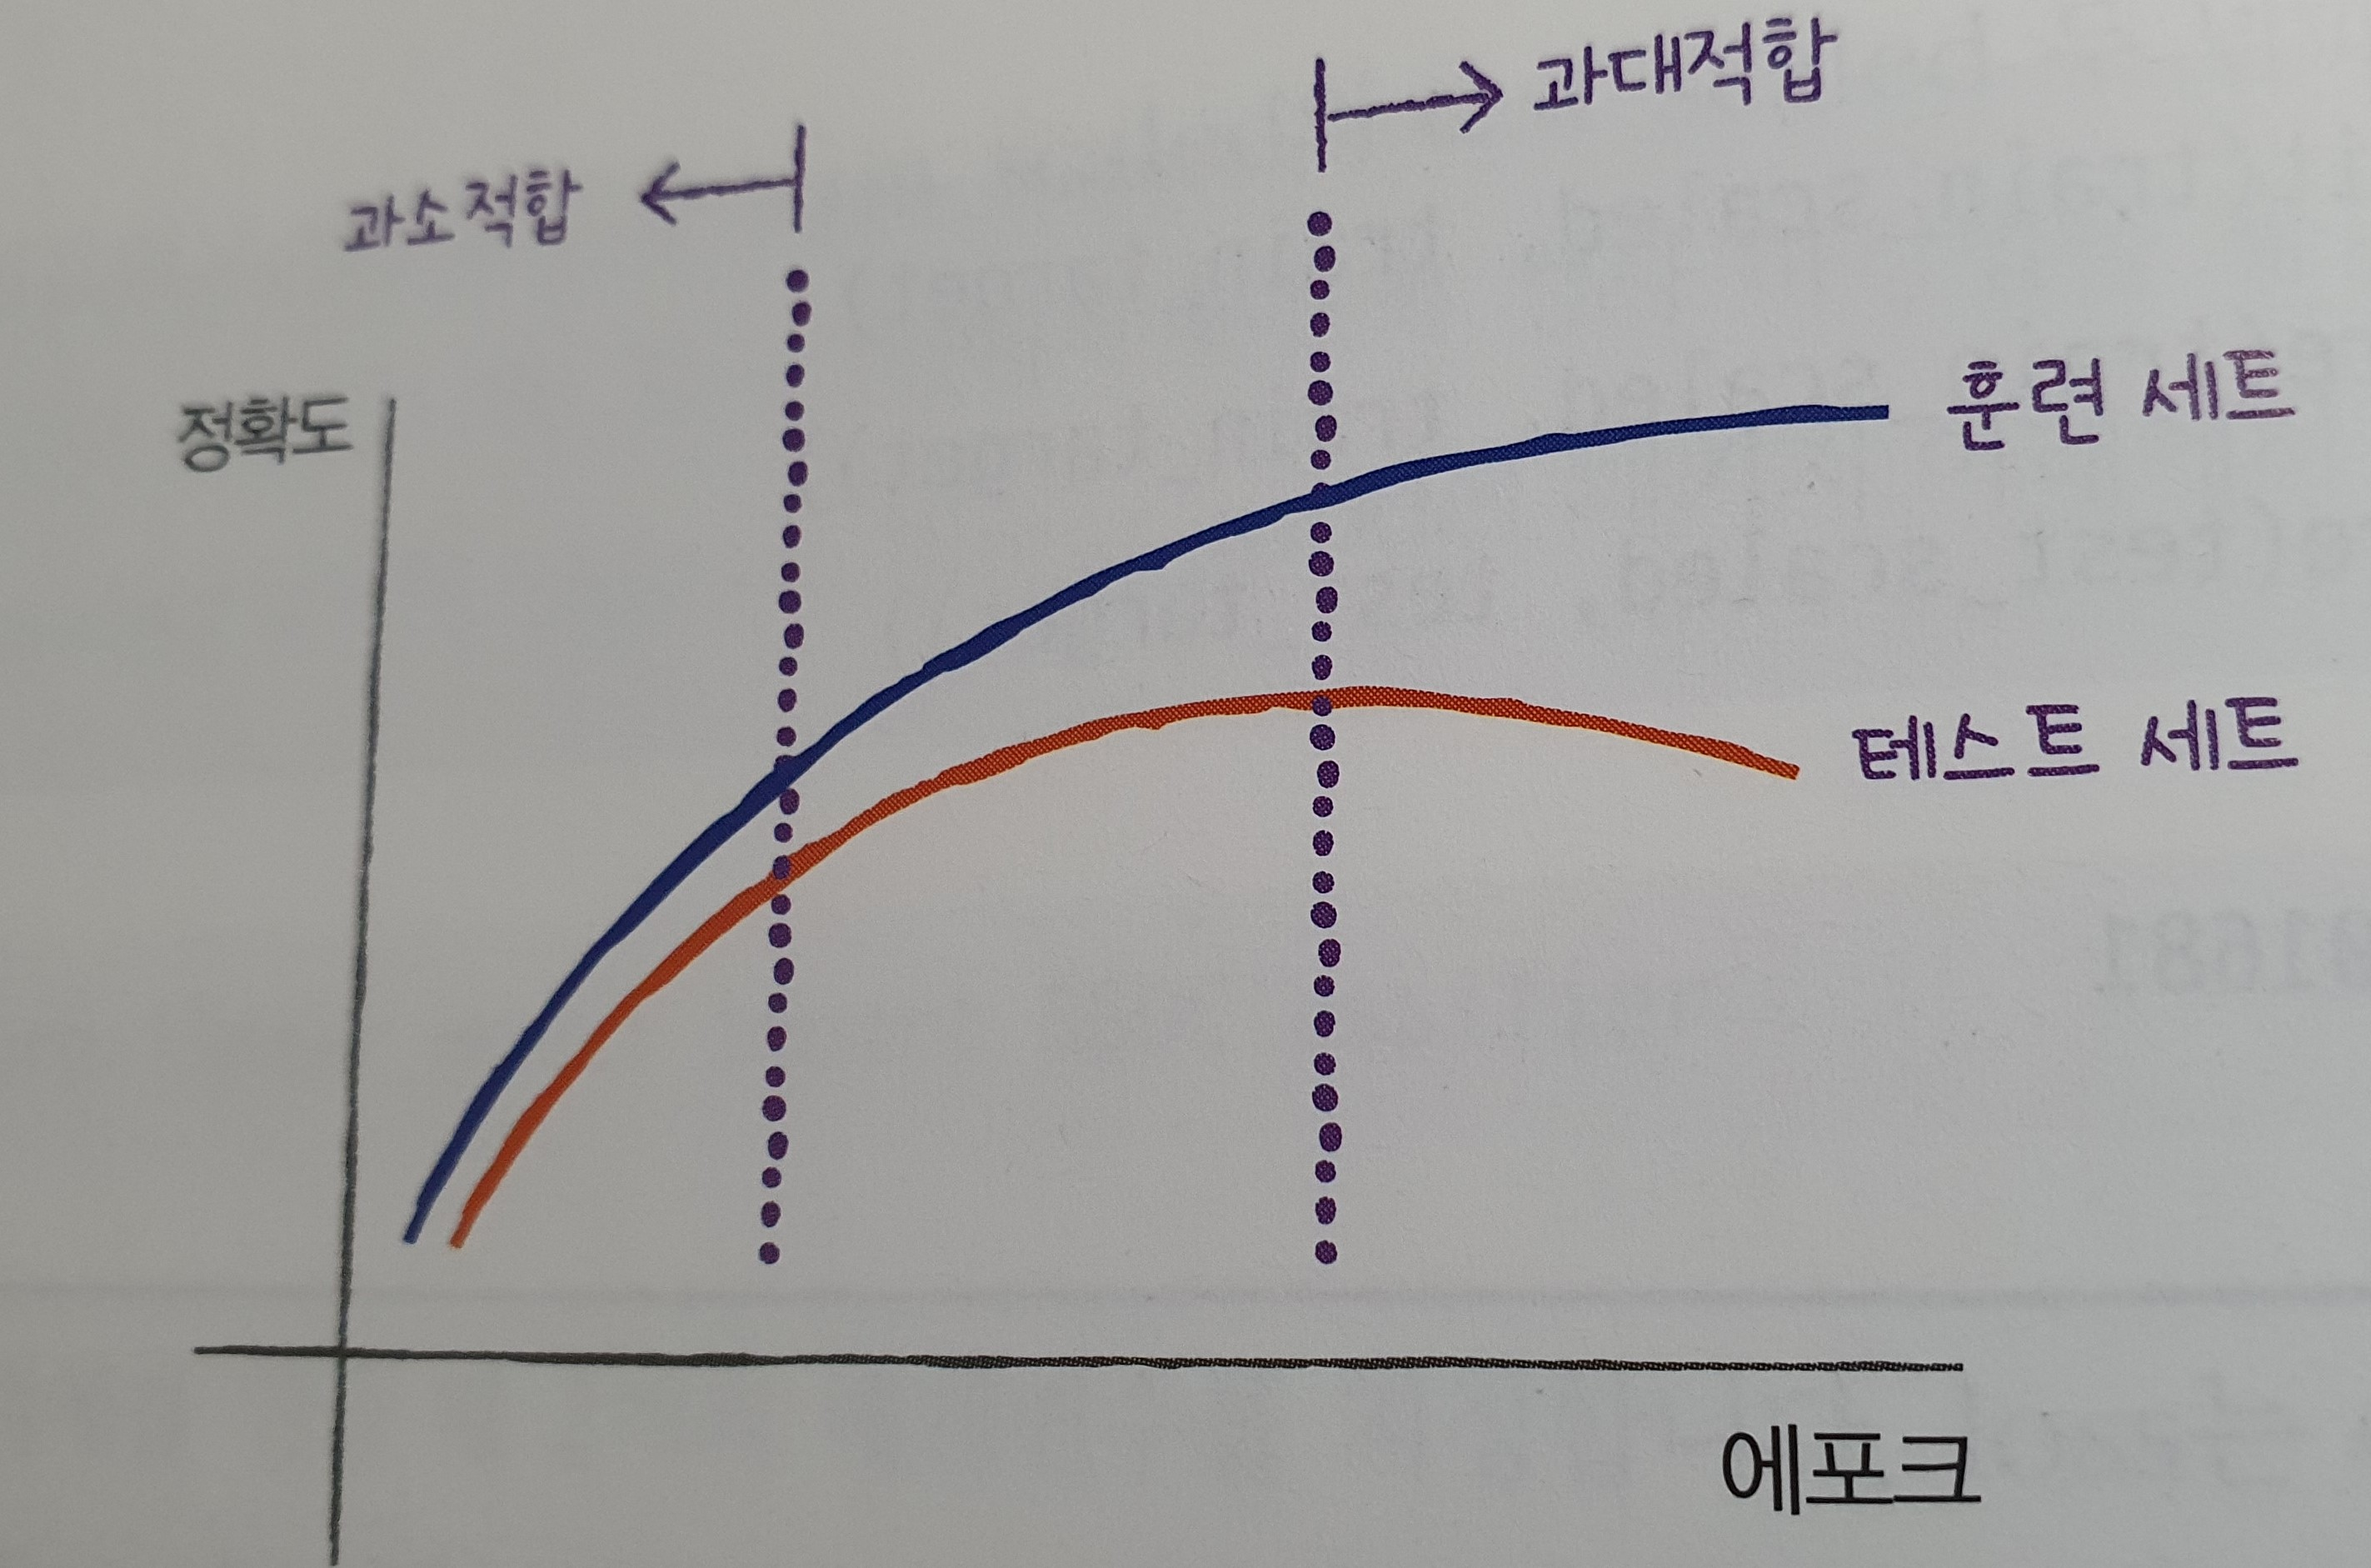

이 그래프는 epoch가 진행됨에 따라 모델의 정확도를 나타낸 그림이다.

**훈련 세트 점수는 에포크가 진행될수록 꾸준히 증가하지만, 테스트 세트 점수는 어느 순간 감소하기 시작한다. 바로 이 지점이 모델이 과대적합되기 시작하는 곳이다.**

과대 적합이 시작하기 전에 훈련을 멈추는 것을 조기 종료(early stopping)라고 한다.

아래 예제부터는 fit()을 사용하지 않고 partial_fit()만 사용한다. partial_fit만 사용하려면 훈련 세트에 있는 전체 클래스의 레이블을 partial_fit에 전달해주어야 한다.

이를 위해 np.unique()함수로 train_target에 있는 7개 생선의 목록을 만든다. 그리고 epoch마다 훈련 세트와 테스트 세트에 대한 점수를 기록하기 위해 2개의 리스트를 만든다.

In [9]:
import numpy as np

sc = SGDClassifier(loss = 'log', random_state=42)
train_score = []
test_score = []
classes = np.unique(train_target)

In [10]:
# 300번의 epoch동안 훈련 반복해본다.
# 반복마다 훈련 세트와 테스트 세트의 점수를 계산하여 train_score, test_score 리스트에 추가한다.

for _ in range(300):
  sc.partial_fit(train_scaled, train_target, classes=classes)
  train_score.append(sc.score(train_scaled, train_target))
  test_score.append(sc.score(test_scaled, test_target))

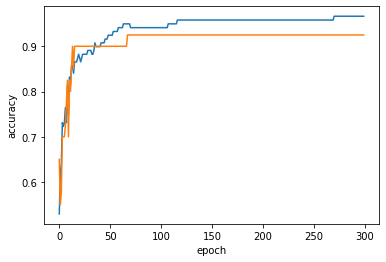

In [11]:
# 300번의 에포크 동안 기록한 훈련 세트와 테스트 세트의 점수를 그래프로 그려보자.

import matplotlib.pyplot as plt

plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

In [12]:
# 파란 색이 훈련 세트의 점수, 주황색이 테스트 세트의 점수이다.
# 대략 100 epoch 이후에는 훈련/테스트 세트의 점수가 조금씩 벌어지고 있다.
# 또, 초기 epoch 에는 과소적합되어 훈련 세트와 테스트 세트의 점수가 낮다.
# 이러한 사실로 봤을 때, 이 모델의 경우 100번째 epoch가 적절한 설정으로 보인다.

# 그럼 SGDClassifier 의 반복횟수를 100으로 맞추고 모델을 다시 훈련해보자.
# 그리고 최종적으로 훈련/테스트 세트의 점수를 출력하자.

sgdc = SGDClassifier(loss='log', max_iter=100, tol=None, random_state=42)
sgdc.fit(train_scaled, train_target)
print(sgdc.score(train_scaled, train_target))
print(sgdc.score(test_scaled, test_target))

0.957983193277311
0.925


In [14]:
# SGDClassifier는 일정 epoch동안 성능이 향상되지 않으면 더 훈련하지 않고 자동으로 멈춘다.
# tol 매개변수에 향상될 최솟값을 지정하는데, 여기서는 None으로 하여 자동으로 멈추지 않고 max_iter만큼 반복하도록 했다.
# 번외로 회귀에 대해서도 확률적 경사하강법이 있는데 SGDRegressor를 쓰면 된다.

# SGDClassifier의 loss 매개변수
# 기본값은 'hinge'로, 힌지 손실은 서포트 벡터 머신이라는 다른 ML 알고리즘을 위한 손실함수이다.

sgdc = SGDClassifier(loss='hinge', max_iter=100, tol=None, random_state=42)
sgdc.fit(train_scaled, train_target)
print(sgdc.score(train_scaled, train_target))
print(sgdc.score(test_scaled, test_target))

0.9495798319327731
0.925


# 4.2.장 정리

> 확률적 경사 하강법

훈련 세트에서 샘플 하나씩 꺼내 손실 함수의 경사를 따라 최적의 모델을 찾는 알고리즘이다.

> 손실 함수

확률적 경사 하강법이 최적화할 대상이다. 이진 분류에는 로지스틱 회귀 손실함수(=이진 크로스엔트로피 손실함수), 다중 분류에는 크로스엔트로피 손실 함수, 회귀 문제에는 MSE 손실함수를 사용한다.

> 에포크

확률적 경사 하강법에서 전체 훈련샘플을 모두 사용하는 한 번 반복을 의미.

특성의 스케일에 영향을 받지 않는것?
LinearRegression.

KNeighborsClassifier는 최근접 이웃을 찾기 위해 샘플 간 거리를 계산하므로, 특성의 스케일을 동일하게 해야함.

Ridge는 가중치를 규제하여 모델의 과대적합을 막음. 특성의 스케일이 다르면 이와 곱해지는 가중치의 스케일도 달라짐. 이렇게되면 큰 가중치에만 관심을 두게 되어 가중치를 공정하게 규제하지 못하게 됨.

SGDClassifier는 손실 함수를 최소화 하기 위해 가장 가파른 경로를 찾는다. Ridge와 같이 특성의 스케일 때문에 가중치의 스케일에 차이가 크면 손실 함수를 최소화하는 경로를 올바르게 판단하지 못함.